Calculating Meta-Lowdin matrix for 6-31g**...
Calculating Meta-Lowdin matrix for cc-pvdz...


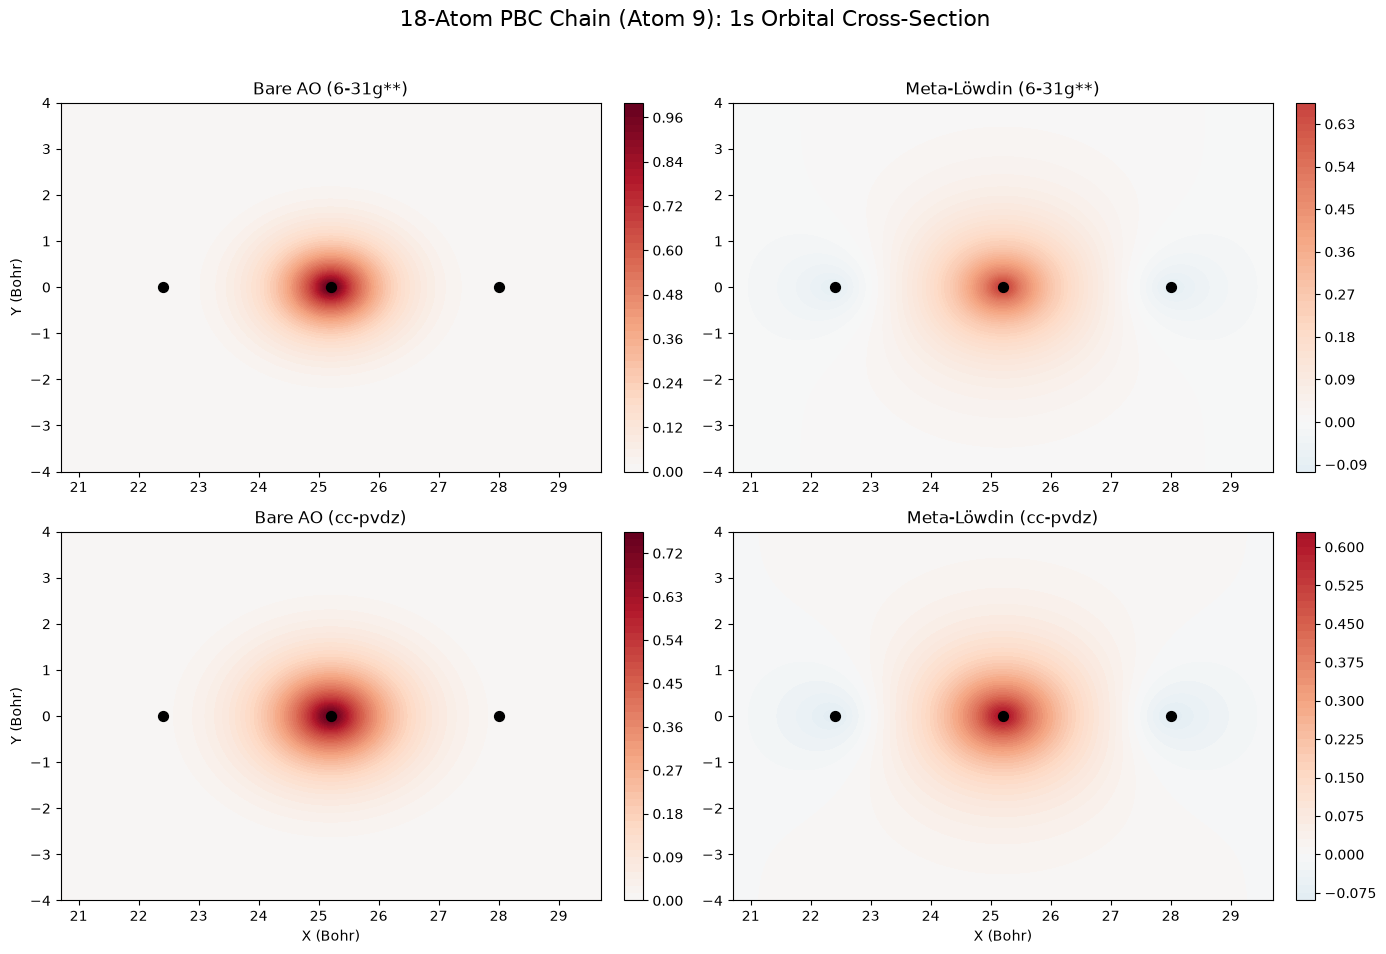

Calculating Meta-Lowdin matrix for 6-31g**...
Calculating Meta-Lowdin matrix for cc-pvdz...


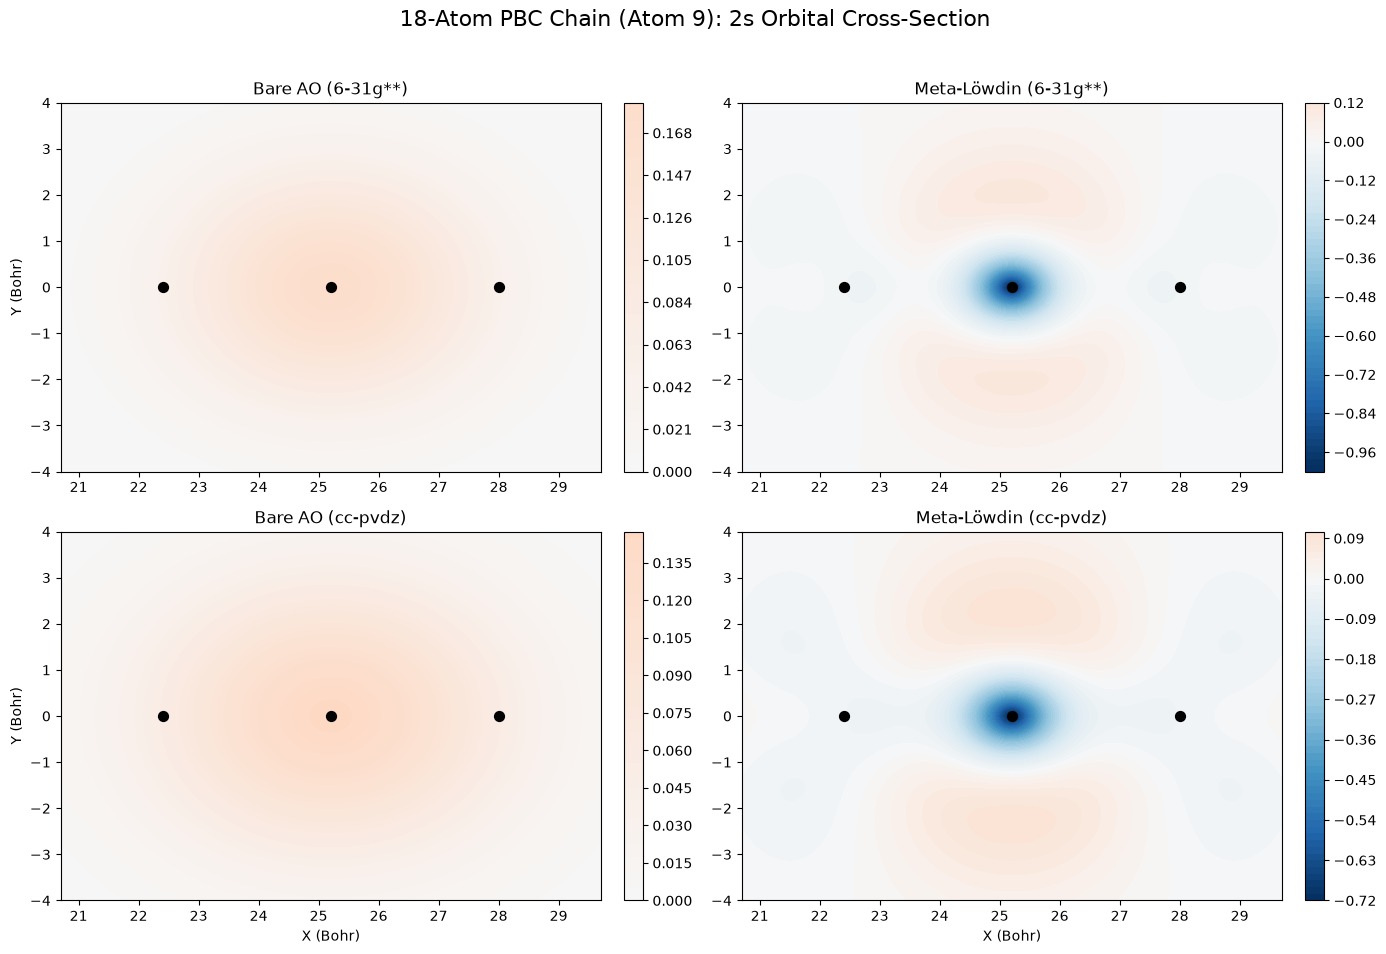

Calculating Meta-Lowdin matrix for 6-31g**...
Calculating Meta-Lowdin matrix for cc-pvdz...


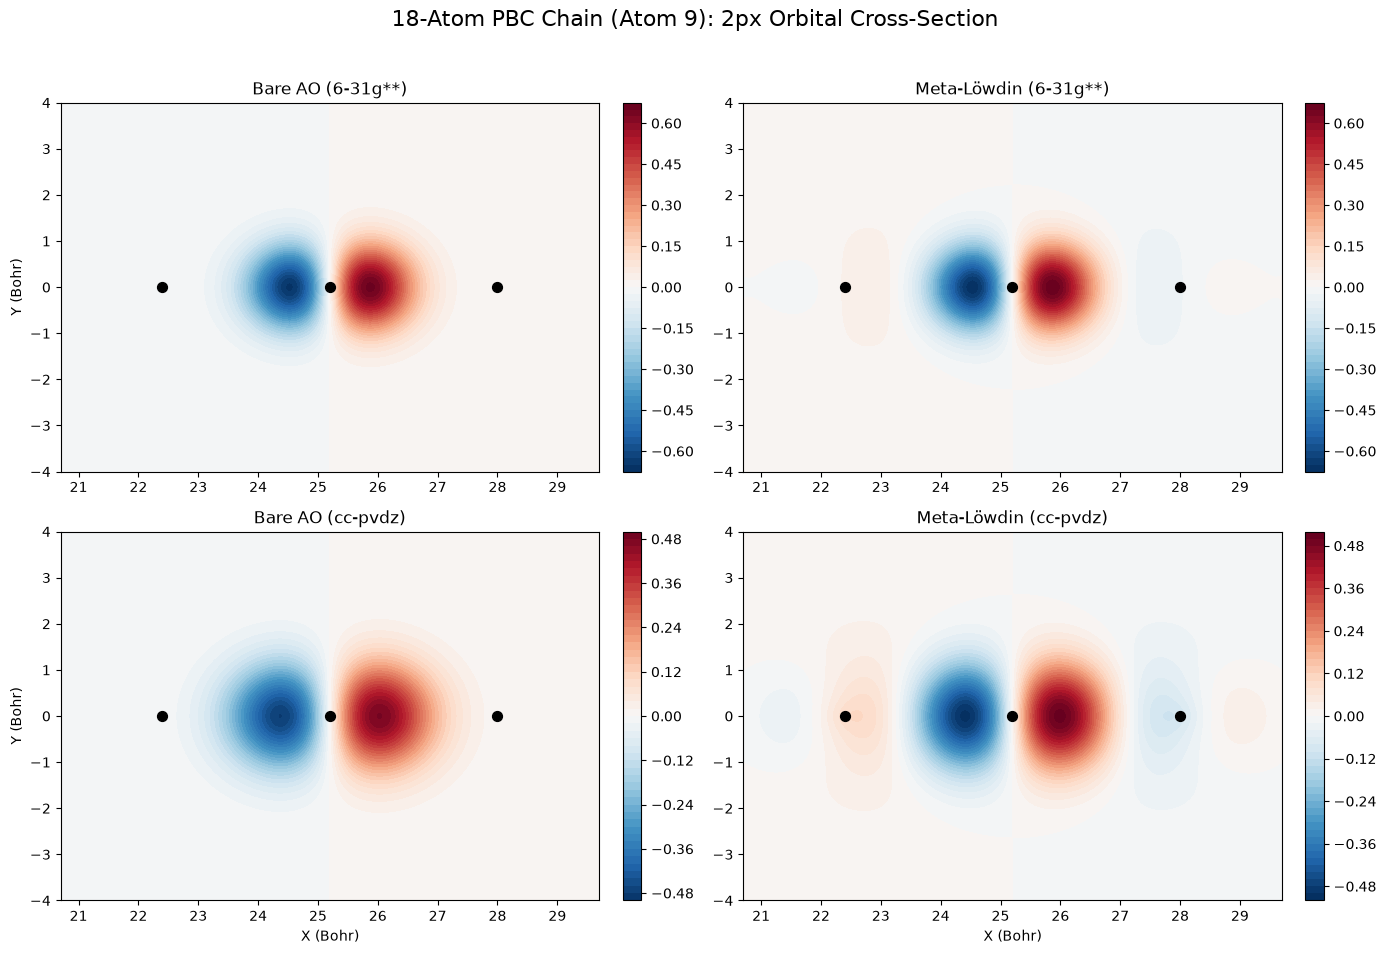

Calculating Meta-Lowdin matrix for 6-31g**...
Calculating Meta-Lowdin matrix for cc-pvdz...


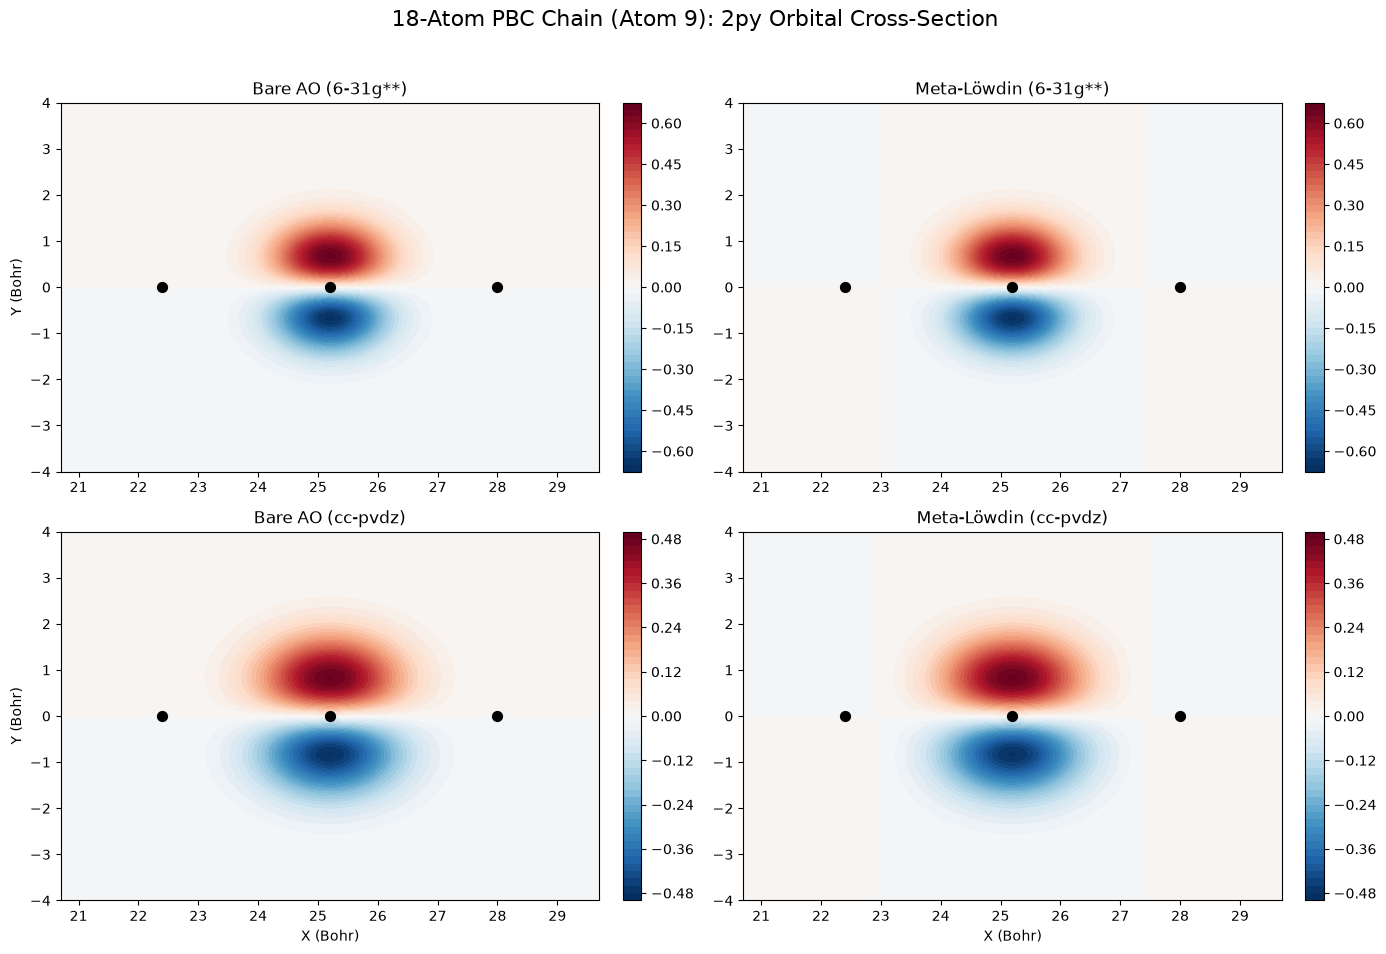

Calculating Meta-Lowdin matrix for 6-31g**...
Calculating Meta-Lowdin matrix for cc-pvdz...


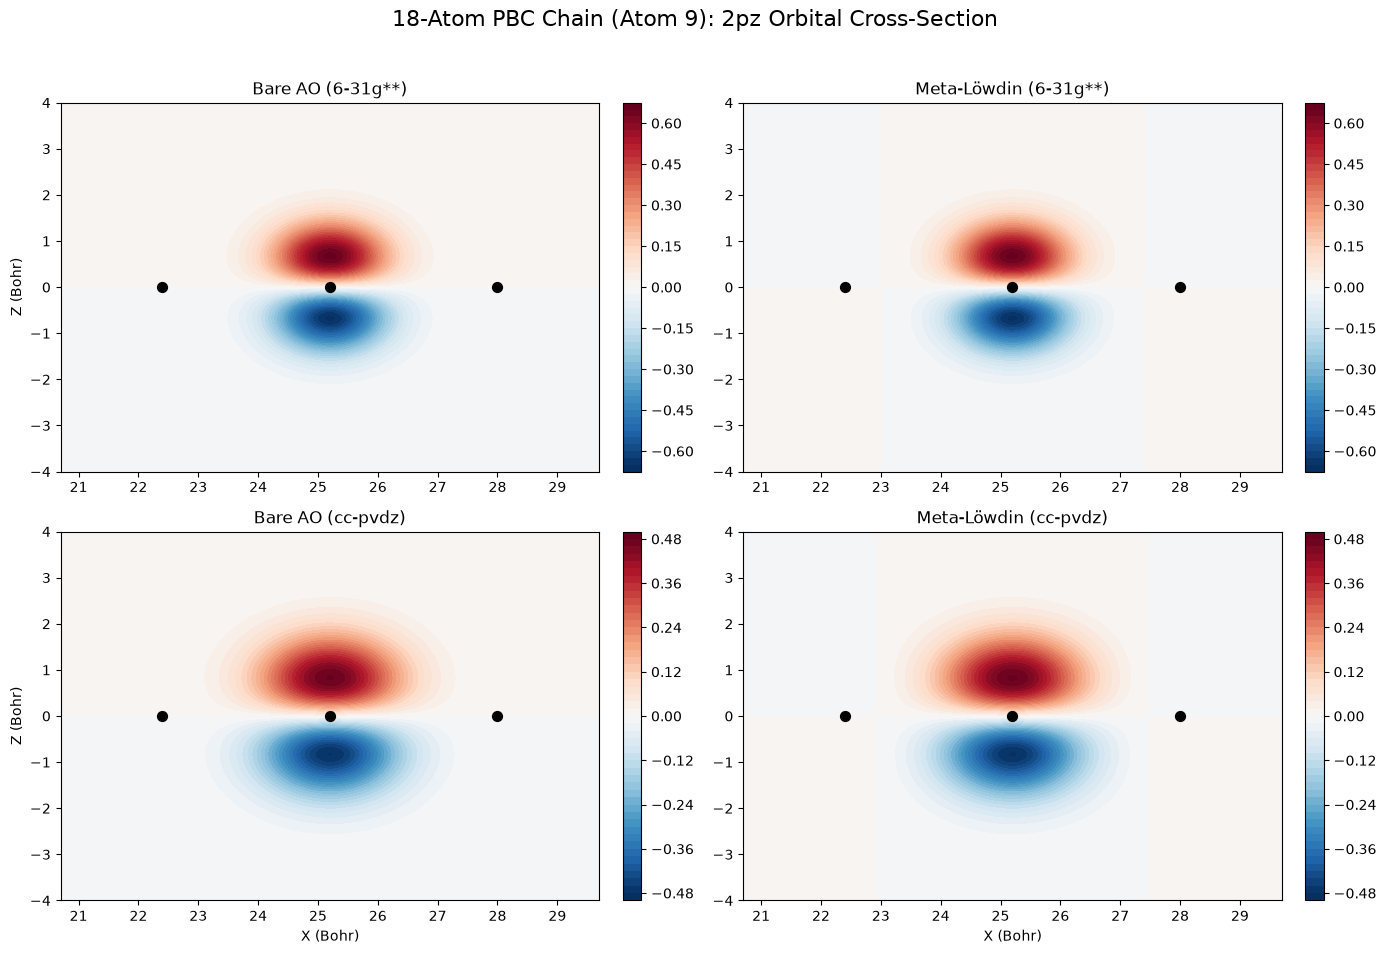

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf.pbc import gto as pbcgto
from pyscf.pbc.tools import pbc as pbctools
from pyscf import lo

# =====================================================================
# 1. System Configuration
# =====================================================================
BASIS_SETS = ['6-31g**', 'cc-pvdz']
ORBITALS_TO_PLOT = ['1s', '2s', '2px', '2py', '2pz']

# 3x3 primitive cell vectors (Bohr)
LATTICE_VECTORS = np.array([
    [5.6, 0.0, 0.0],
    [0.0, 100.0, 0.0],
    [0.0, 0.0, 100.0]
])

# Primitive cell atoms
ATOM_DEF = [
    ['H', [0.0, 0.0, 0.0]],
    ['H', [2.8, 0.0, 0.0]]
]

SUPERCELL_MATRIX = [9, 1, 1]  # 9 copies in x-direction -> 18 atoms total

# =====================================================================
# 2. PySCF PBC Setup & Supercell Generation
# =====================================================================
def get_pbc_supercell_data(basis_name):
    """Builds the 18-atom PBC supercell and computes meta-Lowdin matrices."""
    # 1. Build Primitive Cell
    cell = pbcgto.Cell()
    cell.a = LATTICE_VECTORS
    cell.atom = ATOM_DEF
    cell.basis = basis_name
    cell.unit = 'B'
    cell.spin = 0      # 18 atoms = 18 electrons (closed shell spin=0)
    cell.verbose = 0
    cell.build()
    
    # 2. Build Supercell
    supcell = pbctools.super_cell(cell, SUPERCELL_MATRIX)
    
    # 3. Meta-Löwdin orthogonalization over the supercell (at Gamma point)
    print(f"Calculating Meta-Lowdin matrix for {basis_name}...")
    C_ml = lo.orth_ao(supcell, 'meta-lowdin')
    
    return supcell, C_ml

def find_orbital_index(labels, atom_idx, orb_name):
    """Finds the AO index handling PySCF's spacing format (e.g. '0 H 2p x')."""
    for i, label in enumerate(labels):
        parts = label.split()
        if int(parts[0]) == atom_idx:
            # Reconstruct orbital name without spaces
            orb_str = "".join(parts[2:]) 
            if orb_str == orb_name:
                return i
    return None

# =====================================================================
# 3. Grid Generation (Centered on the middle atoms)
# =====================================================================
# Find the center of the 18-atom chain
# Atoms are at x = 0, 2.8, 5.6, ..., 47.6. Target atom 9 (0-indexed) is at 25.2
TARGET_ATOM_IDX = 9 
center_x = TARGET_ATOM_IDX * 2.8

# Generate grid covering the 3 middle atoms (atoms 8, 9, 10)
x = np.linspace(center_x - 4.5, center_x + 4.5, 250)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

middle_3_atoms_x = [center_x - 2.8, center_x, center_x + 2.8]

# =====================================================================
# 4. Main Plotting Routine
# =====================================================================
for orb_name in ORBITALS_TO_PLOT:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"18-Atom PBC Chain (Atom {TARGET_ATOM_IDX}): {orb_name} Orbital Cross-Section", fontsize=16, y=0.95)
    
    # Slice XZ plane for pz to avoid plotting the nodal plane, XY otherwise
    if 'z' in orb_name:
        coords = np.vstack([X.ravel(), Z.ravel(), Y.ravel()]).T
        y_label = "Z (Bohr)"
    else:
        coords = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
        y_label = "Y (Bohr)"

    for row, basis in enumerate(BASIS_SETS):
        supcell, C_ml = get_pbc_supercell_data(basis)
        labels = supcell.ao_labels()
        
        idx = find_orbital_index(labels, TARGET_ATOM_IDX, orb_name)
        
        if idx is None:
            print(f"Warning: Orbital '{orb_name}' not found for basis {basis}. Skipping.")
            continue
            
        # Evaluate Bare AOs on the grid using periodic boundary conditions
        bare_aos = supcell.pbc_eval_gto("GTOval", coords)
        
        # Compute Meta-Löwdin AOs: phi_ML = phi_bare @ C_ml
        ml_aos = bare_aos @ C_ml
        
        # Extract target AO and reshape back to 2D grid
        val_bare = bare_aos[:, idx].reshape(X.shape)
        val_ml = ml_aos[:, idx].reshape(X.shape)
        
        # Symmetric colormap limits
        vmax = max(np.max(np.abs(val_bare)), np.max(np.abs(val_ml)))
        
        # --- Plot Bare AO ---
        ax = axes[row, 0]
        c1 = ax.contourf(X, Y, val_bare, levels=60, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.scatter(middle_3_atoms_x, [0, 0, 0], color='black', marker='o', s=50, zorder=5, label='H Atoms')
        ax.set_title(f"Bare AO ({basis})")
        ax.set_ylabel(y_label)
        if row == 1: ax.set_xlabel("X (Bohr)")
        fig.colorbar(c1, ax=ax, fraction=0.046, pad=0.04)

        # --- Plot Meta-Löwdin AO ---
        ax = axes[row, 1]
        c2 = ax.contourf(X, Y, val_ml, levels=60, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.scatter(middle_3_atoms_x, [0, 0, 0], color='black', marker='o', s=50, zorder=5)
        ax.set_title(f"Meta-Löwdin ({basis})")
        if row == 1: ax.set_xlabel("X (Bohr)")
        fig.colorbar(c2, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

Calculating Meta-Lowdin matrix for Sc (ccecpccpvdz) and H (6-31g**)...
Calculating Meta-Lowdin matrix for Sc (ccecpccpvdz) and H (cc-pvdz)...


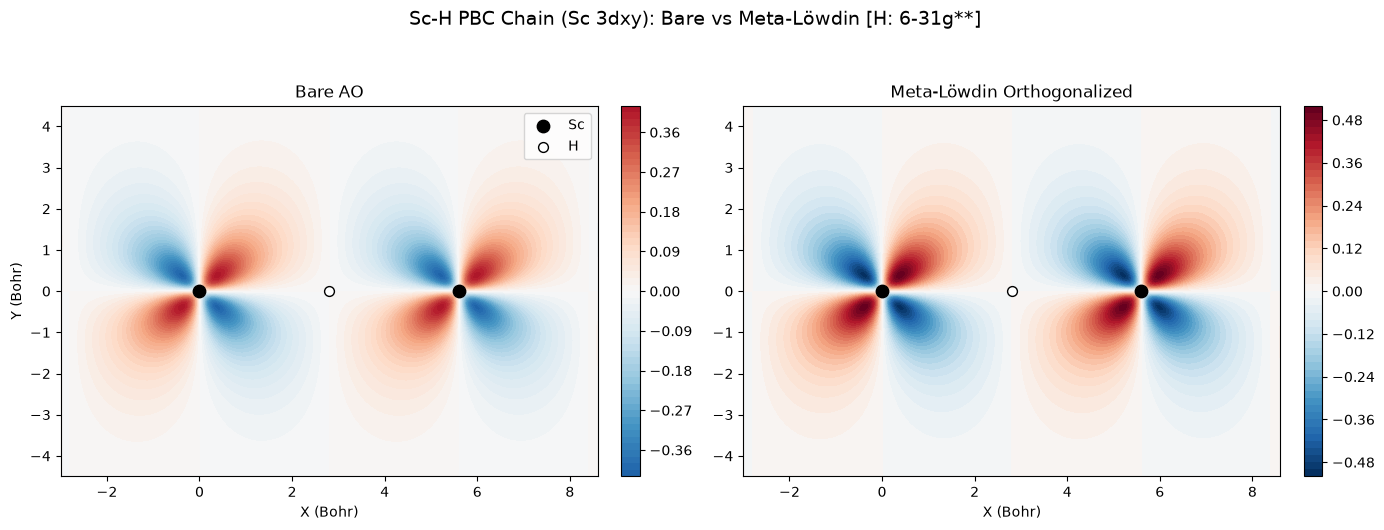

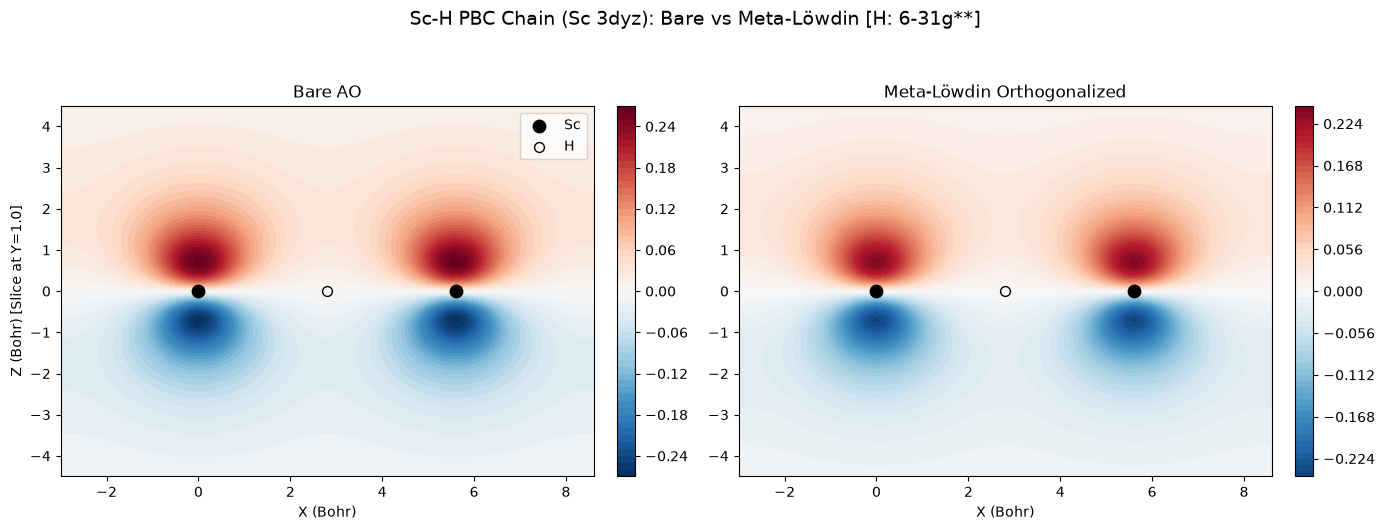

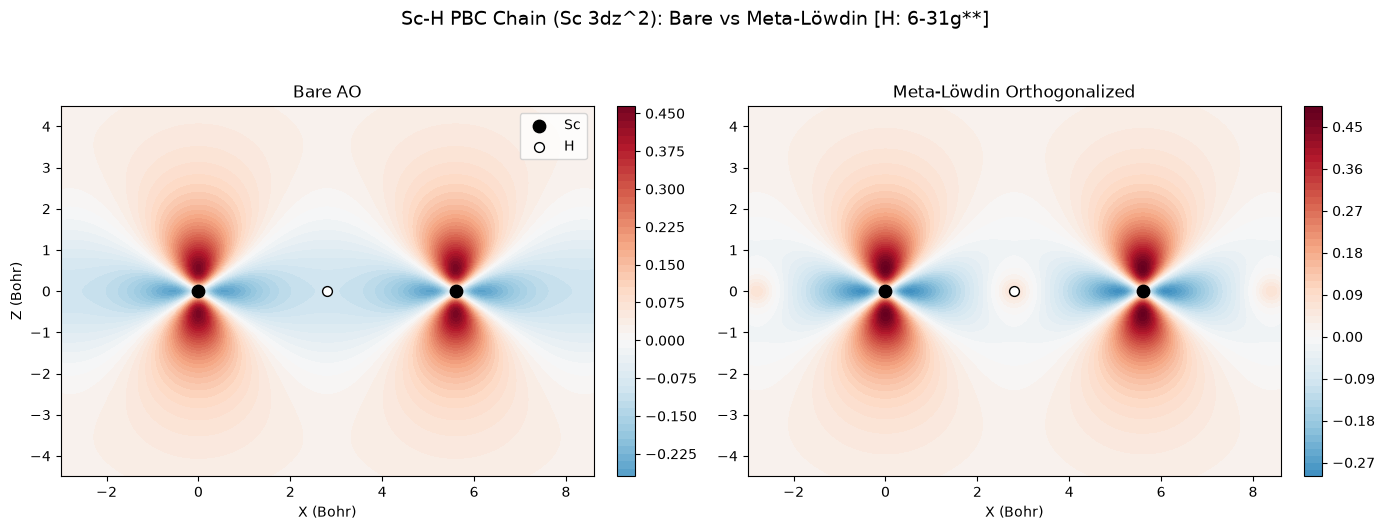

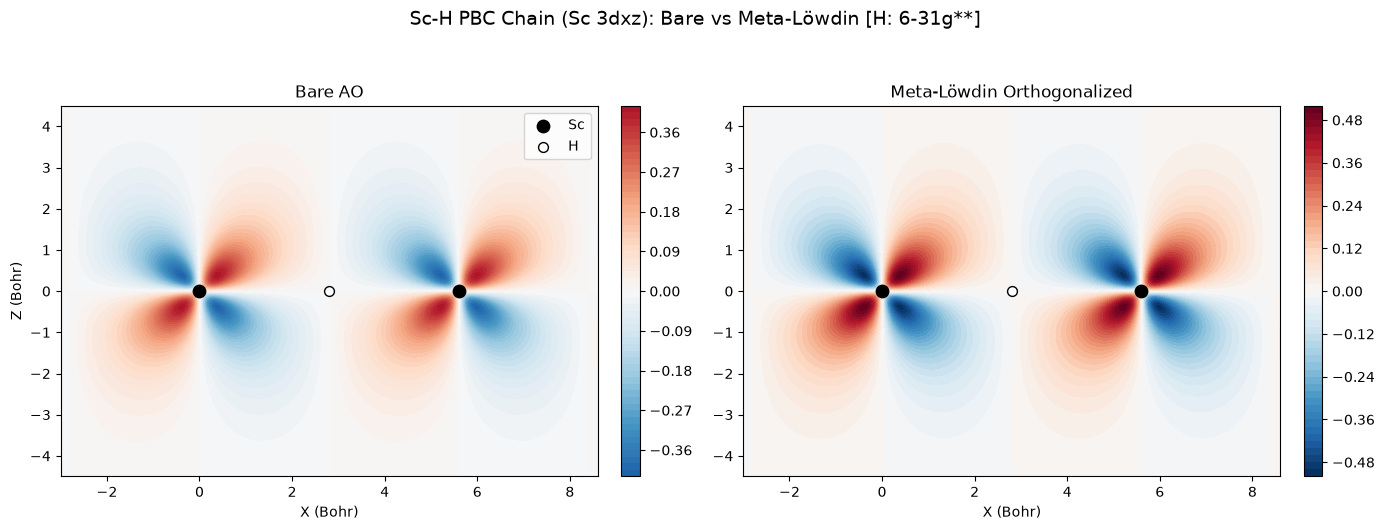

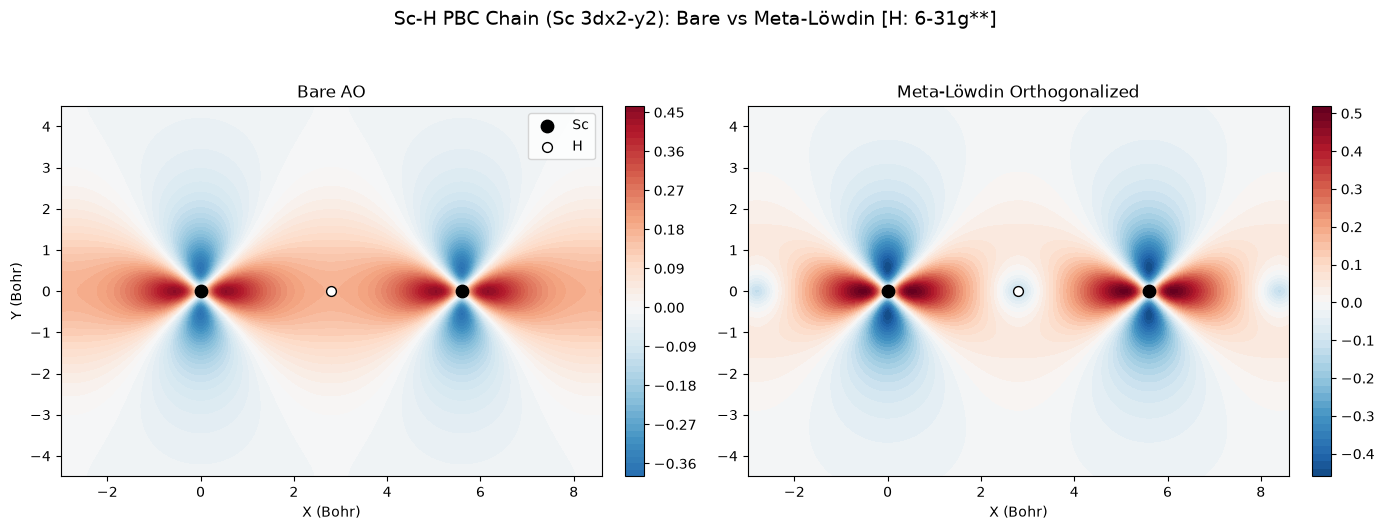

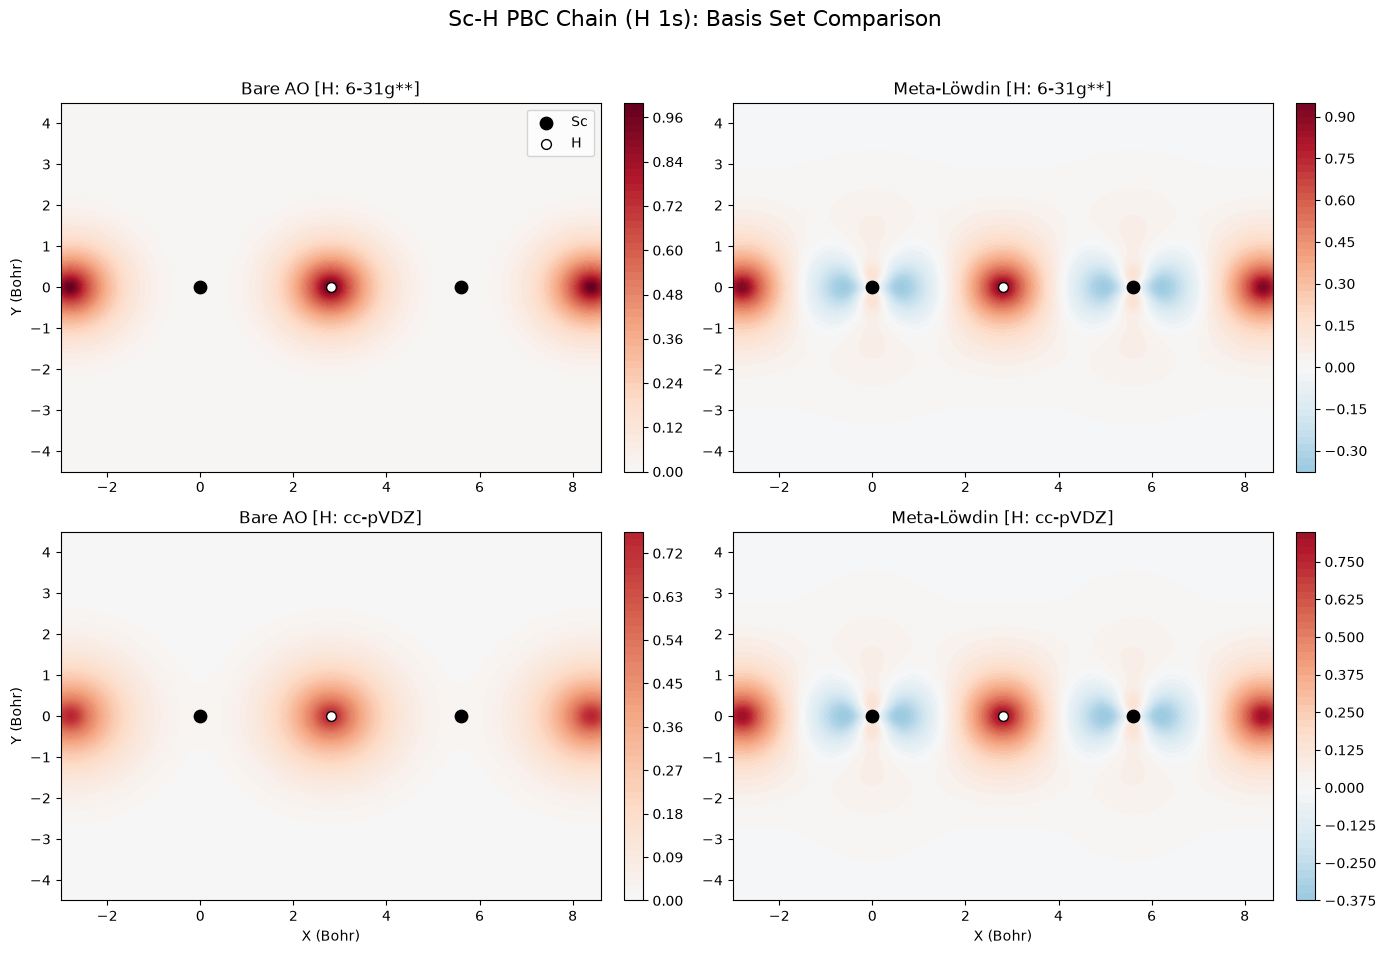

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf.pbc import gto as pbcgto
from pyscf.pbc.tools import pbc as pbctools
from pyscf import lo

# =====================================================================
# 1. System Configuration (Sc-H Chain)
# =====================================================================

# Define both basis configurations for comparison
BASIS_MIXED = {'Sc': 'ccecpccpvdz', 'H': '6-31g**'}
BASIS_CC    = {'Sc': 'ccecpccpvdz', 'H': 'cc-pvdz'}
ECP         = {'Sc': 'ccecp'}

# Target all five 3d orbitals of Sc (atom 0) and the 1s orbital of H (atom 1)
ORBITALS_TO_PLOT = [
    (0, '3dxy'),
    (0, '3dyz'),
    (0, '3dz^2'),
    (0, '3dxz'),
    (0, '3dx2-y2'),
    (1, '1s')
]

# 3x3 primitive cell vectors (Bohr)
LATTICE_VECTORS = np.array([
    [5.6, 0.0, 0.0],
    [0.0, 100.0, 0.0],
    [0.0, 0.0, 100.0]
])

# Primitive cell atoms
ATOM_DEF = [
    ['Sc', [0.0, 0.0, 0.0]],
    ['H',  [2.8, 0.0, 0.0]]
]

SUPERCELL_MATRIX = [1, 1, 1]

# =====================================================================
# 2. PySCF PBC Setup
# =====================================================================
def get_pbc_supercell_data(basis_dict):
    """Builds the 1x1x1 Sc-H cell and computes meta-Lowdin matrices."""
    cell = pbcgto.Cell()
    cell.a = LATTICE_VECTORS
    cell.atom = ATOM_DEF
    cell.basis = basis_dict
    cell.ecp = ECP
    cell.unit = 'B'
    cell.spin = 0  
    cell.verbose = 0
    cell.build()
    
    supcell = pbctools.super_cell(cell, SUPERCELL_MATRIX)
    
    h_basis = basis_dict['H']
    print(f"Calculating Meta-Lowdin matrix for Sc (ccecpccpvdz) and H ({h_basis})...")
    C_ml = lo.orth_ao(supcell, 'meta-lowdin')
    
    return supcell, C_ml

def find_orbital_index(labels, target_atom_idx, orb_name):
    """Finds the AO index handling PySCF's spacing format."""
    for i, label in enumerate(labels):
        parts = label.split()
        if int(parts[0]) == target_atom_idx:
            orb_str = "".join(parts[2:]) 
            if orb_str == orb_name:
                return i
    return None

# =====================================================================
# 3. Compute Orthogonalization Data once for both configurations
# =====================================================================
sup_mixed, C_mixed = get_pbc_supercell_data(BASIS_MIXED)
lbl_mixed = sup_mixed.ao_labels()

sup_cc, C_cc = get_pbc_supercell_data(BASIS_CC)
lbl_cc = sup_cc.ao_labels()

# =====================================================================
# 4. Grid Generation
# =====================================================================
x = np.linspace(-3.0, 8.6, 250)
y = np.linspace(-4.5, 4.5, 200)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

sc_atoms_x = [0.0, 5.6]
h_atoms_x = [2.8]

# =====================================================================
# 5. Main Plotting Routine
# =====================================================================
for atom_idx, orb_name in ORBITALS_TO_PLOT:
    atom_symbol = ATOM_DEF[atom_idx][0]
    
    # Select the optimal slicing plane
    if orb_name == '3dyz':
        coords = np.vstack([X.ravel(), np.ones_like(X.ravel()), Y.ravel()]).T
        y_label = "Z (Bohr) [Slice at Y=1.0]"
    elif 'z' in orb_name:
        coords = np.vstack([X.ravel(), Z.ravel(), Y.ravel()]).T
        y_label = "Z (Bohr)"
    else:
        coords = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
        y_label = "Y (Bohr)"

    # --- Plot logic for Scandium (Maintain 1x2 Layout) ---
    if atom_idx == 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Sc-H PBC Chain ({atom_symbol} {orb_name}): Bare vs Meta-Löwdin [H: 6-31g**]", fontsize=14, y=1.05)
        
        idx = find_orbital_index(lbl_mixed, atom_idx, orb_name)
        if idx is None: continue
            
        bare_aos = sup_mixed.pbc_eval_gto("GTOval", coords)
        ml_aos = bare_aos @ C_mixed
        
        val_bare = bare_aos[:, idx].reshape(X.shape)
        val_ml = ml_aos[:, idx].reshape(X.shape)
        vmax = max(np.max(np.abs(val_bare)), np.max(np.abs(val_ml)))
        
        ax = axes[0]
        c1 = ax.contourf(X, Y, val_bare, levels=60, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.scatter(sc_atoms_x, [0, 0], color='black', marker='o', s=80, zorder=5, label='Sc')
        ax.scatter(h_atoms_x, [0], color='white', edgecolors='black', marker='o', s=50, zorder=5, label='H')
        ax.set_title("Bare AO")
        ax.set_ylabel(y_label)
        ax.set_xlabel("X (Bohr)")
        ax.legend(loc="upper right")
        fig.colorbar(c1, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[1]
        c2 = ax.contourf(X, Y, val_ml, levels=60, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.scatter(sc_atoms_x, [0, 0], color='black', marker='o', s=80, zorder=5)
        ax.scatter(h_atoms_x, [0], color='white', edgecolors='black', marker='o', s=50, zorder=5)
        ax.set_title("Meta-Löwdin Orthogonalized")
        ax.set_xlabel("X (Bohr)")
        fig.colorbar(c2, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

    # --- Plot logic for Hydrogen (2x2 Basis Comparison Layout) ---
    else:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f"Sc-H PBC Chain ({atom_symbol} {orb_name}): Basis Set Comparison", fontsize=16, y=0.95)
        
        configs = [
            ("H: 6-31g**", sup_mixed, C_mixed, lbl_mixed),
            ("H: cc-pVDZ", sup_cc, C_cc, lbl_cc)
        ]
        
        # Pre-compute to find global colormap maximum across both bases
        plot_data = []
        global_vmax = 0.0
        
        for name, sup, C_mat, lbls in configs:
            idx = find_orbital_index(lbls, atom_idx, orb_name)
            if idx is None: continue
            
            bare_aos = sup.pbc_eval_gto("GTOval", coords)
            ml_aos = bare_aos @ C_mat
            val_bare = bare_aos[:, idx].reshape(X.shape)
            val_ml = ml_aos[:, idx].reshape(X.shape)
            
            local_max = max(np.max(np.abs(val_bare)), np.max(np.abs(val_ml)))
            global_vmax = max(global_vmax, local_max)
            plot_data.append((name, val_bare, val_ml))
            
        for row, (name, val_bare, val_ml) in enumerate(plot_data):
            # Bare AO
            ax = axes[row, 0]
            c1 = ax.contourf(X, Y, val_bare, levels=60, cmap='RdBu_r', vmin=-global_vmax, vmax=global_vmax)
            ax.scatter(sc_atoms_x, [0, 0], color='black', marker='o', s=80, zorder=5, label='Sc')
            ax.scatter(h_atoms_x, [0], color='white', edgecolors='black', marker='o', s=50, zorder=5, label='H')
            ax.set_title(f"Bare AO [{name}]")
            ax.set_ylabel(y_label)
            if row == 1: ax.set_xlabel("X (Bohr)")
            if row == 0: ax.legend(loc="upper right")
            fig.colorbar(c1, ax=ax, fraction=0.046, pad=0.04)

            # Meta-Löwdin AO
            ax = axes[row, 1]
            c2 = ax.contourf(X, Y, val_ml, levels=60, cmap='RdBu_r', vmin=-global_vmax, vmax=global_vmax)
            ax.scatter(sc_atoms_x, [0, 0], color='black', marker='o', s=80, zorder=5)
            ax.scatter(h_atoms_x, [0], color='white', edgecolors='black', marker='o', s=50, zorder=5)
            ax.set_title(f"Meta-Löwdin [{name}]")
            if row == 1: ax.set_xlabel("X (Bohr)")
            fig.colorbar(c2, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()